In [2]:
# Tutorial
# https://nbviewer.org/github/OpenPIV/openpiv-python-examples/blob/main/notebooks/PIV_3D_example.ipynb
# GUI: https://pypi.org/project/openpivgui/

In [3]:
from openpiv.pyprocess3D import *
from openpiv.PIV_3D_plotting import *
from openpiv.validation import sig2noise_val
from openpiv.filters import replace_outliers
from openpiv.lib import replace_nans
import glob as glob
import numpy as np
import cv2
import os
from natsort import natsorted
import matplotlib.animation as animation

In [4]:
# before_directory = 'data/data-PIV3D-1/BEFORE.tif.frames/'
# after_directory  = 'data/data-PIV3D-1/AFTER .tif.frames/'

before_directory = 'data/data-PIV3D-2/before.tif.frames/'
after_directory  = 'data/data-PIV3D-2/after.tif.frames/'

In [5]:

# Convert from RGB to grayscale
def RGB_TO_GRAY(image):
    # return np.dot(image[..., :3], [0.2989, 0.5870, 0.1140])
    return np.dot(image[..., :3], [1/3, 1/3, 1/3])

# def RGB_TO_GRAY(image):
# 	return np.array(cv2.cvtColor(image, cv2.COLOR_GRAY2BGR))


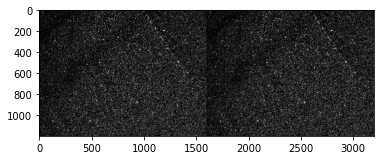

In [6]:
# Load image stacks

before_images = natsorted(glob.glob(os.path.join(before_directory, "before_C001Z*.tif")))
after_images  = natsorted(glob.glob(os.path.join(after_directory, "after_C001Z*.tif")))

before_sample = RGB_TO_GRAY(plt.imread(before_images[0]))
after_sample  = RGB_TO_GRAY(plt.imread(after_images[0]))

image_shape = before_sample.shape

# Display a before and after slice
plt.imshow(np.hstack([before_sample, after_sample]), cmap = plt.get_cmap('gray'))

In [7]:

# Load images into 3D stack array
before_array = np.zeros((image_shape[0], image_shape[1], len(before_images)))
after_array  = np.zeros((image_shape[0], image_shape[1], len(after_images)))

for i, image in enumerate(before_images):
	before_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

for i, image in enumerate(after_images):
	after_array[:, :, i] = RGB_TO_GRAY(plt.imread(image))

before_array.shape

(1200, 1600, 35)

In [8]:
x_dim = 32
y_dim = 32
z_dim = 6

win_overlap = 0.5

window_size = (x_dim, y_dim, z_dim)
overlap = (int(x_dim * win_overlap), int(y_dim * win_overlap), int(z_dim * win_overlap))
search_area = (x_dim, y_dim, z_dim)

In [9]:
# Calculate 3D Particle Image Velocimetry
# https://openpiv.readthedocs.io/en/latest/src/openpiv.html

u, v, w, sig2noise = extended_search_area_piv3D(
	before_array, after_array, 
	window_size = window_size, 
	overlap = overlap,
	search_area_size = search_area, 
	subpixel_method = 'gaussian',
	sig2noise_method = 'peak2peak',
	width = 2
)

100%|██████████| 74/74 [06:39<00:00,  5.40s/it]


In [10]:
# Correcting stage drift between the field of views
u -= np.nanmean(u)
v -= np.nanmean(v)
w -= np.nanmean(w)

In [11]:
u.shape, v.shape, w.shape

((74, 99, 10), (74, 99, 10), (74, 99, 10))

In [12]:
# Filtering
# mask = sig2noise_val(sig2noise, threshold=signoise_filter)
# uf, vf, wf = replace_outliers(u, v, w, mask, w=w, max_iter=1, tol=100, kernel_size=2, method='disk')

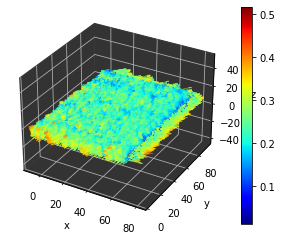

In [13]:
fig1 = quiver_3D(-u, v, w, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5}) #, filter_def=0.1)
plt.savefig(f'results/Quiver_Displacement_{x_dim}x{y_dim}x{z_dim}_dpi600_downsample1.png', dpi = 600)

In [14]:
u.mean(), v.mean(), w.mean()

(3.103653773453891e-18, 5.043437381862573e-17, 6.789242629430387e-19)

In [15]:
# # filtered 3d deformation field
# fig12 = quiver_3D(-uf, vf, wf, quiv_args={"length": 2, "alpha": 0.8, "linewidth": 1}) #, filter_def=0.1)

In [16]:
# Calculate strain from displacement

import numpy as np

U = u
V = v
W = w

# Calculate displacement gradients
dUdx, dUdy, dUdz = np.gradient(U)
dVdx, dVdy, dVdz = np.gradient(V)
dWdx, dWdy, dWdz = np.gradient(W)

# Compute strain tensor components
Exx = dUdx  # Strain in x
Eyy = dVdy  # Strain in y
Ezz = dWdz  # Strain in z
Exy = 0.5 * (dUdy + dVdx)  # Shear strain xy
Eyz = 0.5 * (dVdz + dWdy)  # Shear strain yz
Exz = 0.5 * (dUdz + dWdx)  # Shear strain xz

# Create a list of strain tensors for each point in space
shape = U.shape
Strain = np.empty(shape + (3, 3))

for i in range(shape[0]):
    for j in range(shape[1]):
        for k in range(shape[2]):
            Strain[i, j, k] = np.array([[Exx[i, j, k], Exy[i, j, k], Exz[i, j, k]],
                                        [Exy[i, j, k], Eyy[i, j, k], Eyz[i, j, k]],
                                        [Exz[i, j, k], Eyz[i, j, k], Ezz[i, j, k]]])

# 'Strain' now contains the strain tensors for each point in space


In [17]:
# Extract the diagonal elements of the strain tensor at each grid point
# Diagonal elements represent principal strains in each direction
E_xx = Strain[..., 0, 0]
E_yy = Strain[..., 1, 1]
E_zz = Strain[..., 2, 2]


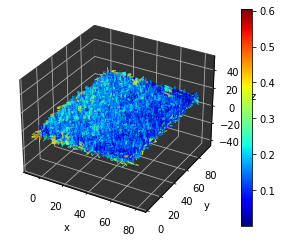

In [18]:
# Display strain magnitudes and directions

fig2 = quiver_3D(E_xx, E_yy, E_zz, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5})#, filter_def=0.1)
plt.savefig('results/Quiver_Strain_dpi600_downsample1.png', dpi = 600)

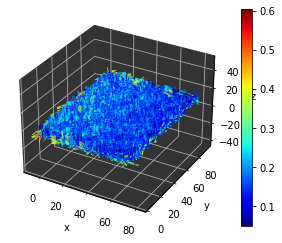

In [19]:

# Threshold away very small strains
eps = 0.05

# Find where magnitudes are less than some insignificant number
Mag = np.sqrt((E_xx * E_xx) + (E_yy * E_yy) + (E_zz * E_zz))
small = np.abs(Mag) < eps

# Thresholded strain tensors
E_xx_t = E_xx.copy()
E_yy_t = E_yy.copy()
E_zz_t = E_zz.copy()

# Set 
E_xx_t[small] = 0.0
E_yy_t[small] = 0.0
E_zz_t[small] = 0.0

fig3 = quiver_3D(E_xx_t, E_yy_t, E_zz_t, filter_reg = 1, quiv_args={"length": 0.05, "alpha": 0.8, "linewidth": 0.5})
plt.savefig('results/Quiver_Strain_dpi600_downsample1_thres005.png', dpi = 600)

(152, 505)


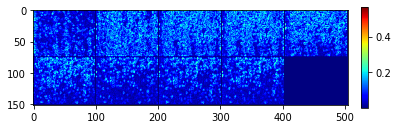

In [65]:
# 2D heatmaps of intensity of vectors on each layer

# print(Mag.shape)

pad = 2
blocks = np.zeros((Mag.shape[0] * 2 + pad * 2, Mag.shape[1] * 5 + pad * 5))
# blocks = np.ones((Mag.shape[0], Mag.shape[1] * Mag.shape[2] + pad * Mag.shape[2]))
print(blocks.shape)

# grid = np.array()
grid = Mag[:, :, 0]

row = 0
col = 0

for i in range(1, Mag.shape[2]):
	layer = Mag[:, :, i]

	blocks[row : row + layer.shape[0], col : col + layer.shape[1]] = layer

	col += layer.shape[1] + pad
	if i % 5 == 0:
		row += layer.shape[0] + pad
		col = 0

	grid = np.hstack([grid, layer])

plt.imshow(blocks, cmap = plt.get_cmap('jet'), vmin = layer.min(), vmax = layer.max())
plt.colorbar(fraction = 0.02, aspect = 15, pad = 0.04)
plt.savefig('results/Slices_Strain_Magnitudes_dpi600.png', dpi = 600)
plt.show()


In [21]:
# Calculate traction force

# Define the Young's Modulus (E) for the material
E = 1.03e8 # Pa (N/m^2)

# Define the area over which you want to calculate traction force
area_width = 0.1   # Width of the area in meters
area_length = 0.1  # Length of the area in meters
area_height = 0.1  # Height of the area in meters

# Calculate the stress tensor from the strain tensor and Young's Modulus
stress_tensor = E * Strain

# Calculate the traction force by integrating the stress tensor over the selected area
traction_force = np.sum(stress_tensor) * area_width * area_length * area_height

# Print the calculated traction force
print("Traction Force:", traction_force, "N")

Traction Force: -80728441.17300062 N
